In [ ]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time
import os
from queer.functions import get_rotation_matrix

In [9]:
# Input files
file_path = "./Ag_primitive/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=8.310342,poscar='POSCAR')
g_vec = model.g_vec

In [10]:
k_points = 200
custom_points = [
    [0, 0, 0],   # Gamma
    [1/2, 0, 1/2],     # X
    [1/2, 1/4, 3/4],   # W
    [0.375, 0.375, 3/4], # K
    [0, 0, 0],     # Gamma
    [1/2, 1/2, 1/2] # L
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['Γ', 'X', 'W', 'K', 'Γ', 'L']

Calculating band structure...


Plotting band structure...


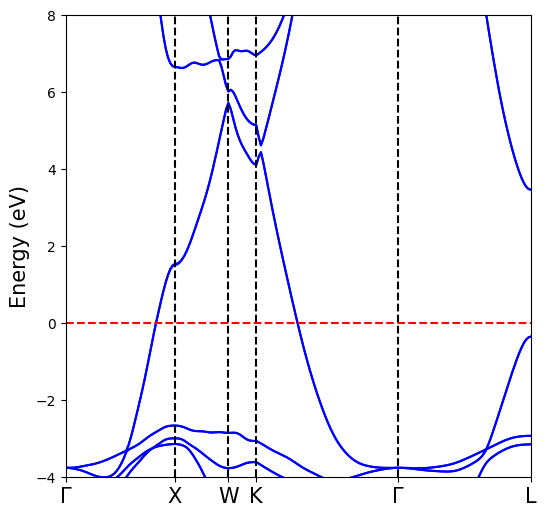

In [11]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,8])


In [12]:
k_points = 200
custom_points = [
    [1/2, 1/2, 1/2], # L
    [1/2, 1/4, 3/4],   # W
    [0.375, 0.375, 3/4], # K
    [1/2, 1/2, 1/2] # L    
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['L', 'W', 'K','L']

Calculating band structure...
Plotting band structure...


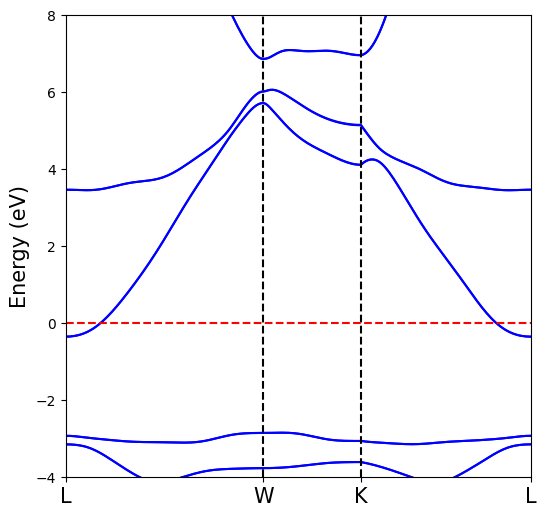

In [13]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,8])


In [ ]:
#GMKG path shifted on L direction


In [27]:
np.linspace(0,1,6)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

/tmp/ipykernel_1353016/535243719.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 21)


Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...
Calculating band structure...


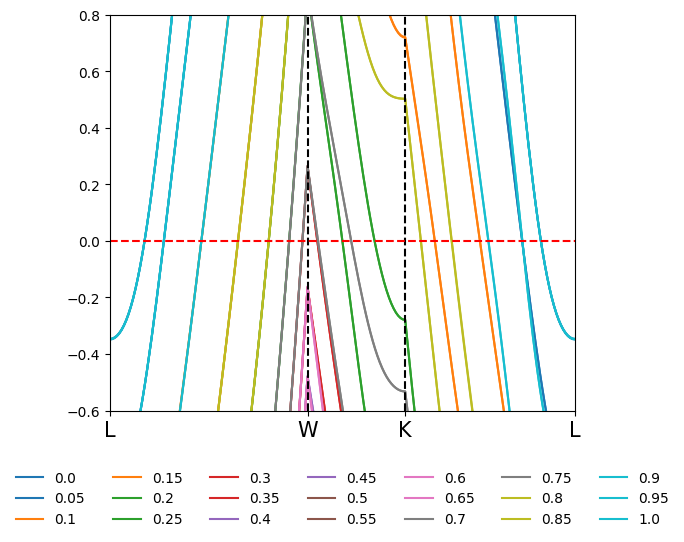

In [37]:
k_points = 200
labels = ['L', 'W', 'K','L']
custom_points = np.array([
    [1/2, 1/2, 1/2], # L
    [1/2, 1/4, 3/4],   # W
    [0.375, 0.375, 3/4], # K
    [1/2, 1/2, 1/2] # L    
])
plt.figure(figsize=(6, 6))
cmap = plt.cm.get_cmap('tab10', 21)
for j, shift in enumerate(np.linspace(0, 1, 21)):
    new_points = custom_points + shift
    # Create the path
    corner_points, path = path_create(k_points, new_points)
    sym = corner_points

    # Calculate band dispersion along the path
    print("Calculating band structure...")
    bands = model.calculate_energy(path)
    
    color = cmap(j)
    for b_idx, band in enumerate(bands):
        label = f"{shift.round(3)}" if b_idx == 0 else None
        plt.plot(band, color=color, label=label)


plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
for s in sym[1:-1]:
    plt.axvline(s, c="black", linestyle="--")
plt.axhline(0, linestyle="--", color="red")
plt.ylim(-0.6, 0.8)

# leave space for legend
plt.subplots_adjust(bottom=0.22)

# legend outside bottom
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=7,              # adjust to taste
    frameon=False,
    fontsize=10
)

plt.show()

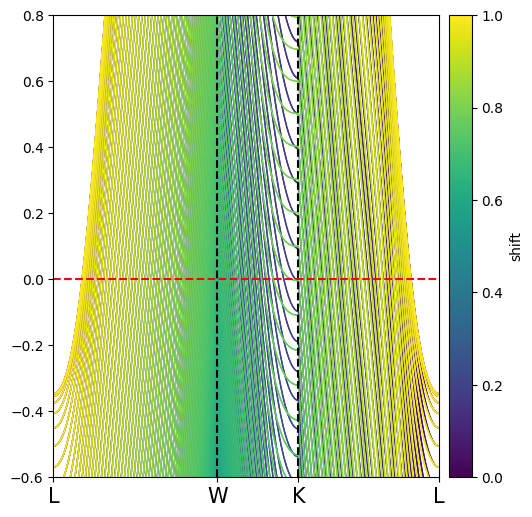

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

k_points = 200
labels = ['L', 'W', 'K', 'L']
custom_points = np.array([
    [1/2, 1/2, 1/2],      # L
    [1/2, 1/4, 3/4],      # W
    [0.375, 0.375, 3/4],  # K
    [1/2, 1/2, 1/2],      # L
], dtype=float)

# -----------------------
# 1) PRECOMPUTE (ONCE)
# -----------------------
# Build base path once (sym positions won't change under uniform shift)
corner_points, base_path = path_create(k_points, custom_points)
sym = corner_points

# choose more shifts (increase N for finer/continuous sampling)
N = 201
shifts = np.linspace(0.0, 1.0, N)

# Precompute and store bands: shape -> (N, n_bands, n_k)
bands_list = []
for shift in shifts:
    path_shift = base_path + shift
    bands = model.calculate_energy(path_shift)   # expected iterable of bands
    bands = np.asarray(bands)                    # (n_bands, n_k)
    bands_list.append(bands)

bands_all = np.stack(bands_list, axis=0)         # (N, n_bands, n_k)



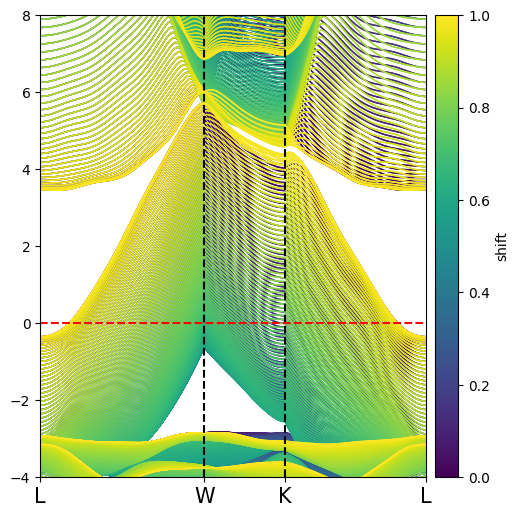

In [50]:

# -----------------------
# 2) PLOT (NO RECALC)
# -----------------------
fig, ax = plt.subplots(figsize=(6, 6))

cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=shifts.min(), vmax=shifts.max())

for i, shift in enumerate(shifts):
    color = cmap(norm(shift))
    for b in range(bands_all.shape[1]):
        ax.plot(bands_all[i, b], color=color, linewidth=1.0)

ax.set_xticks(sym)
ax.set_xticklabels(labels, fontsize=15)
ax.set_xlim(sym[0], sym[-1])

for s in sym[1:-1]:
    ax.axvline(s, c="black", linestyle="--")

ax.axhline(0, linestyle="--", color="red")
ax.set_ylim(-4, 8)

# Continuous colorbar (better than legend when N is large)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("shift", rotation=90)

plt.show()

In [7]:
N = 300
factor = 4

In [8]:
kx,ky,kz = mesh_cartesian(N=[N,N,1],factor=factor).T-factor/2

In [9]:
K = np.array([kx,ky,kz])
K= (K.T + np.array([0,0,factor/2])).T


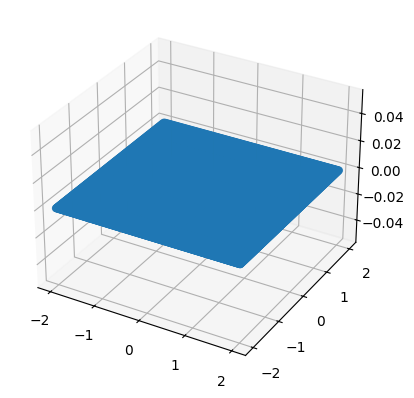

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(K[0],K[1],K[2])
plt.show()

In [ ]:
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])

rot_mesh = rot_mat@K

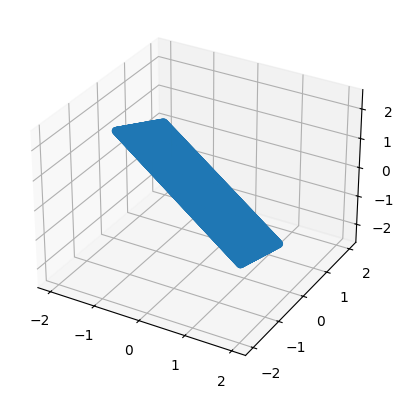

In [13]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(rot_mesh[0],rot_mesh[1],rot_mesh[2])

plt.show()

In [14]:
K

array([[-2.        , -2.        , -2.        , ...,  2.        ,
         2.        ,  2.        ],
       [-2.        , -1.98662207, -1.97324415, ...,  1.97324415,
         1.98662207,  2.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(3, 90000))

In [15]:
g_vec = model.g_vec

In [16]:
inv_mesh = angstrom2reciprocal(rot_mesh.T,g_vec=model.g_vec)

In [17]:
inv_kmesh = crystal2cartesian(rot_mesh, g_vec)
band = model.calculate_energy(inv_kmesh) 

In [18]:
band.shape

(18, 90000)

In [19]:
band.shape

(18, 90000)

In [20]:
K.shape

(3, 90000)

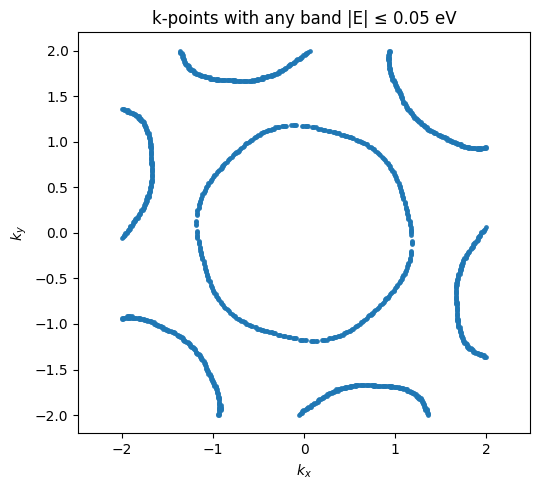

In [21]:
delta = 0.05  # eV
nband, nk = band.shape
kx, ky, kz = K  # each (nk,)

# Points where at least one band is near zero
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)

plt.figure(figsize=(5.5, 5))
plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9)
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(f"k-points with any band |E| ≤ {delta} eV")
plt.tight_layout()
plt.axis("equal")
plt.show()


In [53]:
np.linalg.norm(model.g_vec[0])/2

np.float64(1.3257607887159917)

In [ ]:
z_slice = np.linspace(0,1.32,30)

In [23]:
import numpy as np

# Given:
# K.shape == (3, nk) with K[2, :] == 0
nk = K.shape[1]

# Choose the kz sampling (either by count or step)
n_kz = 10  # e.g., 67 slices → linspace(0, 1.32, 67)
# step = 0.02
# n_kz = int(np.floor(1.32/step)) + 1
kz_vals = np.linspace(0.0, 1.32, n_kz)  # (n_kz,)

# --- Option A: stack of K arrays: (n_kz, 3, nk) ---
Ks = np.repeat(K[np.newaxis, :, :], n_kz, axis=0)  # (n_kz, 3, nk)
Ks[:, 2, :] = kz_vals[:, None]                     # broadcast kz onto each slice

# Example: Ks[i] is the full (3, nk) K array at kz = kz_vals[i]
print(Ks.shape, kz_vals[0], kz_vals[-1])  # (n_kz, 3, nk) 0.0 1.32
                     # (3, n_kz*nk)


(10, 3, 90000) 0.0 1.32


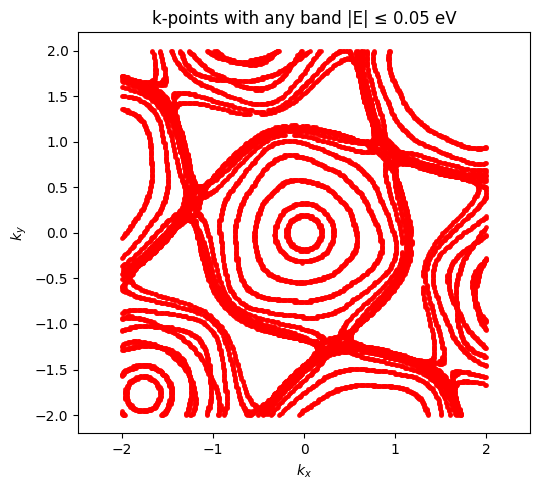

In [159]:
plt.figure(figsize=(5.5, 5))
energies = []
for z_slice in Ks:
    rot_mesh = rot_mat@z_slice
    inv_kmesh = crystal2cartesian(rot_mesh, g_vec)
    band = model.calculate_energy(inv_kmesh)
    energies.append(band)
    delta = 0.05  # eV
    nband, nk = band.shape
    near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
    plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(f"k-points with any band |E| ≤ {delta} eV")
plt.tight_layout()
plt.axis("equal")
plt.show()


In [99]:
N = 200
factor = 4
binding_range = [0, 0.05]
binding_step = 0.1
photon_energy = 21.2
fermi_energy = 0
V0 = 15
binding_energy=0

In [103]:
K = mesh_cartesian(N=[N, N, 1], factor=factor).T  # shape (3, N*N*1)
K[:2, :] -= factor / 2.0    
kx,ky,kz = K
Ek = 21.2
kz = arpes_equation(Ek, V0, [kx,ky])
K = kx,ky,kz
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
rot_mesh = rot_mat@K
inv_mesh_array = crystal2cartesian(rot_mesh, g_vec)

In [104]:
band = model.calculate_energy(inv_mesh_array)

(np.float64(-2.136683417085427),
 np.float64(2.1969849246231155),
 np.float64(-2.136683417085427),
 np.float64(2.1969849246231155))

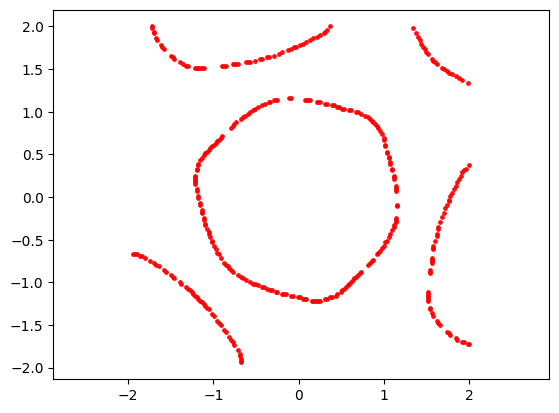

In [105]:
delta = 0.05  # eV
nband, nk = band.shape
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')
plt.axis("equal")

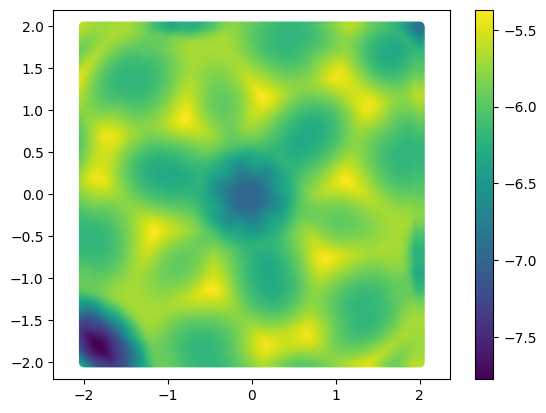

In [110]:
for i in band:
    plt.scatter(kx,ky,c=i)
    plt.colorbar()
    plt.axis("equal")
    plt.show()


In [33]:
mesh_array =  np.array(arpes_mesh(photon_energy,fermi_energy,binding_energy,V0,N,factor,align=[[0,0,1],[1,1,1]]))

In [82]:
inv_mesh_array = crystal2cartesian(mesh_array, g_vec)
    

In [83]:
band = model.calculate_energy(inv_mesh_array)

In [91]:
band.shape

(18, 90000)

ValueError: 'c' argument has 90000 elements, which is inconsistent with 'x' and 'y' with size 40000.

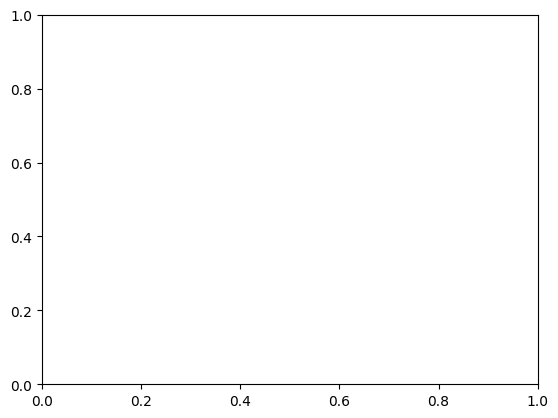

In [ ]:
for i in band:
    plt.scatter(kx,ky,c=i)
    plt.show()

In [84]:
delta = 0.05  # eV
nband, nk = band.shape
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 40000 but size of corresponding boolean axis is 90000

In [32]:
mesh_array.shape

(3, 90000)

In [ ]:
inv_mesh = rot_mat@mesh_array

In [ ]:
inv_mesh

In [ ]:
rot_mat.T@inv_mesh

In [ ]:
mesh_array =  np.array(arpes_mesh(photon_energy,fermi_energy,binding_energy,V0,N,factor,align=[[0,0,1],[1,1,1]]))

In [ ]:
# Function to format time in a readable way
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f} seconds"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.2f} minutes"
    else:
        hours = seconds / 3600
        return f"{hours:.2f} hours"

In [ ]:
N = 200
factor = 4
binding_range = [0, 3.1]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = [15]
align = [[0,0,1],[1,1,1]]
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
energy_shift=[-2,0,2]
for shift in energy_shift:
    for v in V0:
        kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range, binding_step, v, N, factor,align)

        start_total = time.time()
        # Energy calculations
        start_energy = time.time()
        energy_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            inv_kmesh = crystal2cartesian(kmesh, g_vec)
            band = model.calculate_energy(inv_kmesh) 
            energy_dict[i] = band + shift
        end_energy = time.time()
        print(f"Energy calculations took {format_time(end_energy - start_energy)}")

        # Data processing: mesh tiling to intensity calculation
        start_data = time.time()
        mesh_tile_dict = {}
        band_tile_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            tile_mesh = []
            for k in range(energy_dict[i].shape[0]):
                tile_mesh.append(kmesh.T)
            mesh_tile = np.array(tile_mesh).reshape(-1, 3)
            mesh_tile_dict[i] = mesh_tile
            band_tile = energy_dict[i].flatten()
            band_tile_dict[i] = band_tile

        df_dict = {}
        for i, j in kmesh_dict.items():
            mesh_tile = mesh_tile_dict[i]
            band_tile = band_tile_dict[i]
            df = pd.DataFrame()
            df['kx'] = mesh_tile.T[0]
            df['ky'] = mesh_tile.T[1]
            df['kz'] = mesh_tile.T[2]
            df['e'] = band_tile
            df_dict[i] = df

        df_shift = {name: df.copy(deep=True) for name, df in df_dict.items()}
        energy_shift = df_shift[0].query('e<=0').max().e

        for i, j in df_shift.items():
            j.e -= energy_shift

        intensity_dict = {}
        for i, j in df_shift.items():
            j["I"] = np.exp(-((j.e + i)**2) / (2 * 0.1**2))
            group_max = j.loc[j.groupby(['kx', 'ky'])['I'].idxmax()]
            intensity_dict[i] = group_max
        end_data = time.time()
        print(f"Data processing took {format_time(end_data - start_data)}")
        start_plot = time.time()
        for i, j in intensity_dict.items():
            K = np.array([j.kx,j.ky,j.kz])
            inv_trans = rot_mat.T@K
            fig = plt.figure(figsize=(5, 5))
            plt.scatter(inv_trans[0], inv_trans[1], c=j.I, cmap='inferno', s=1)
            # plt.scatter(j.kx, j.ky, c=j.I, cmap='inferno', s=1)
            plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
            plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
            plt.title(fr"${{E_B}}$={np.around(i,2)} eV")
            # plt.title(fr"${{V_0}}$={v} eV")
            plt.gca().set_facecolor('black')
            # plt.xlim(-2, 2)
            # plt.ylim(-2, 2)
            plt.tight_layout()
            os.makedirs(f'Ag_primitive/figs/V0_{v}_shift_{shift}', exist_ok=True)    
            figure_path = f"Ag_primitive/figs/V0_{v}_shift_{shift}/{np.around(i,2)}.png"
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            # frame_files.append(figure_path)
            # plt.close(fig)  # Close figure to free memory instead of showing
        end_plot = time.time()
        print(f"Plotting took {format_time(end_plot - start_plot)}")

        # Total execution time
        end_total = time.time()
        print(f"Total execution time: {format_time(end_total - start_total)}")

In [ ]:
intensity_dict[0].kx

In [ ]:
plt.scatter(intensity_dict[0].kx,intensity_dict[0].ky)

In [ ]:
K = np.array([intensity_dict[0].kx,intensity_dict[0].ky,intensity_dict[0].kz])

In [ ]:
inv_trans = rot_mat.T@K

In [ ]:
plt.scatter(inv_trans[0],inv_trans[1])

In [ ]:
np.dot(rot_mat,np.array([0,0,1]))

In [ ]:
mesh

In [ ]:
intensity_dict

In [ ]:
kmesh.shape

In [ ]:
df_shift

In [ ]:
bands = model.calculate_energy(path)
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()


In [ ]:
curved_path = arpes_path(path,g_vec,Ek=21.2,V0=15)
bands = model.calculate_energy(curved_path)

In [ ]:
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))


In [ ]:
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()

In [ ]:
v0_array = [15]
deltaE=np.linspace(0,-3,300)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(path,g_vec,Ek=21.2-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


In [ ]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=sym, labels=labels, fontsize=15)
    plt.xlim(sym[0], sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    plt.savefig(f'figs/arpes_path/k_400/V0_{j}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()
